In [22]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

print("Imported Successfully")

Imported Successfully


In [23]:
# !unzip data_2.zip

In [24]:
data = []
labels = []

categories = ["yes", "no"]

for category in categories:
    path = f"data/classification/{category}"

    label = categories.index(category)

    if not os.path.exists(path):
        print(f"Error: Path not found -> {path}")
        continue

    for img_name in os.listdir(path):

        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (128,128))

        data.append(img)
        labels.append(label)

X = np.array(data) / 255.0
y = np.array(labels)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Images shape: (38, 128, 128, 3)
Labels shape: (38,)


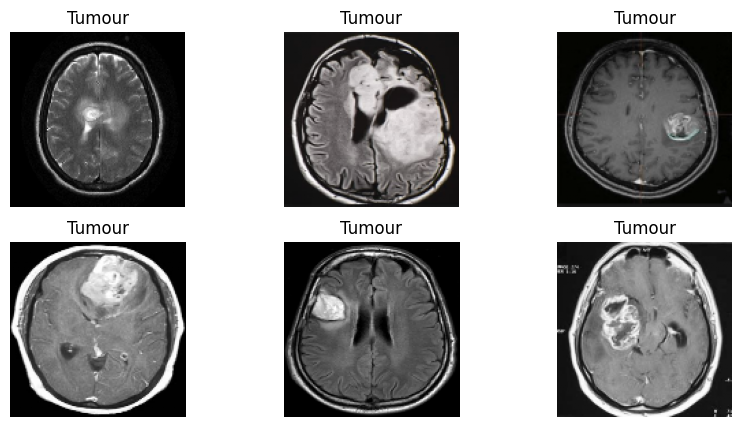

In [25]:
plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(X[i])
    plt.title("Tumour" if y[i]==0 else "No Tumour")
    plt.axis("off")

plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test_val, y_test_val)
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step - accuracy: 0.9667 - loss: 0.1816 - val_accuracy: 0.8333 - val_loss: 0.2561
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step - accuracy: 0.9333 - loss: 0.1645 - val_accuracy: 0.8333 - val_loss: 0.2050
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step - accuracy: 0.9333 - loss: 0.1372 - val_accuracy: 0.8333 - val_loss: 0.1749
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step - accuracy: 0.9667 - loss: 0.1008 - val_accuracy: 0.8333 - val_loss: 0.1589
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9667 - loss: 0.0763 - val_accuracy: 1.0000 - val_loss: 0.1110


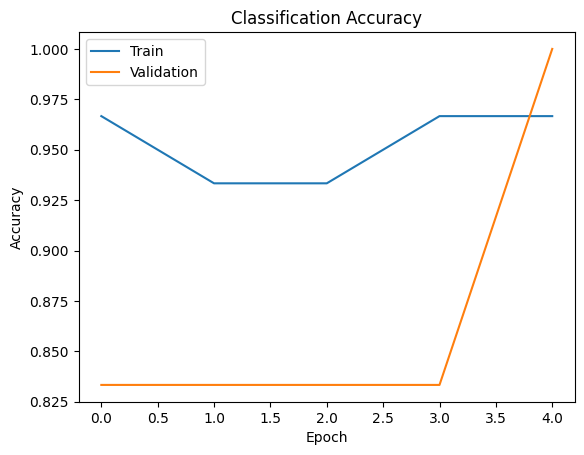

In [38]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Classification Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


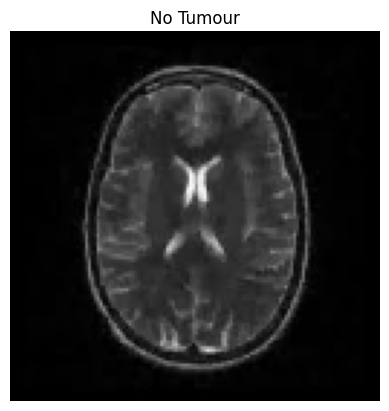

In [35]:
sample = X_test[7]

prediction = model.predict(np.expand_dims(sample, axis=0))

plt.imshow(sample)

if prediction > 0.5:
    plt.title("No Tumour")
else:
    plt.title("Tumour")

plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


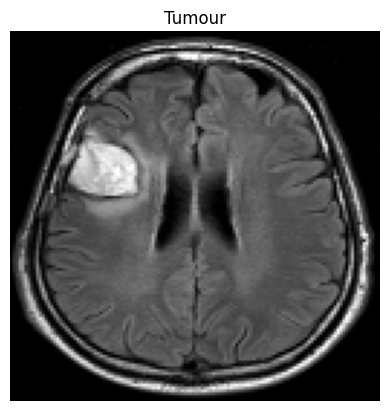

In [36]:
sample2 = X_test[2]

prediction = model.predict(np.expand_dims(sample2, axis=0))

plt.imshow(sample2)

if prediction > 0.5:
    plt.title("No Tumour")
else:
    plt.title("Tumour")

plt.axis("off")
plt.show()